# Publisher coverage

Figure D11 counts bibliography records by publisher and publication period before abstract triage. Duplicate DOI rows remain in the counts.

In [1]:
from pathlib import Path
import csv
import hashlib
import json
import sys
import matplotlib
matplotlib.use("Agg")
from IPython.display import Image, Markdown, display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "src/mofinder/plotting/literature_triage_figures.py").exists())
sys.path.insert(0, str(ROOT / "src"))
from mofinder.plotting.literature_triage_figures import (
    PERIOD_LABELS, summarize_publishers, draw_publisher_coverage,
)
FIGURES = ROOT / "docs/triage_figures"
manifest = json.loads((FIGURES / "provenance.json").read_text(encoding="utf-8"))
for name, expected_hash in manifest["files"].items():
    assert hashlib.sha256((FIGURES / name).read_bytes()).hexdigest() == expected_hash, name


## Count records

Map each indexed publisher name to one family and count records in each publication period.

In [2]:
summary = summarize_publishers(
    FIGURES / "publisher_source_records.csv", FIGURES / "publisher_name_mapping.csv"
)
actual = {row["Publisher"]: row["Total"] for row in summary}
assert actual == manifest["expected_publisher_totals"]
assert sum(actual.values()) == manifest["record_count"]
with (FIGURES / "publisher_source_records.csv").open(encoding="utf-8", newline="") as handle:
    rows = list(csv.DictReader(handle))
unique_dois = {row["DOI"].strip().lower() for row in rows if row["DOI"].strip()}
assert len(unique_dois) == manifest["unique_nonempty_doi_count"]
with (ROOT / "data/processed_data/literature_metadata.csv").open(encoding="utf-8-sig", newline="") as handle:
    metadata = list(csv.DictReader(handle))
assert [row["DOI"].strip().lower() for row in rows] == [row["DOI"].strip().lower() for row in metadata]
print(f"{len(rows):,} bibliography records; {len(unique_dois):,} unique DOIs.")

13,773 bibliography records; 13,770 unique DOIs.


## Draw Figure D11

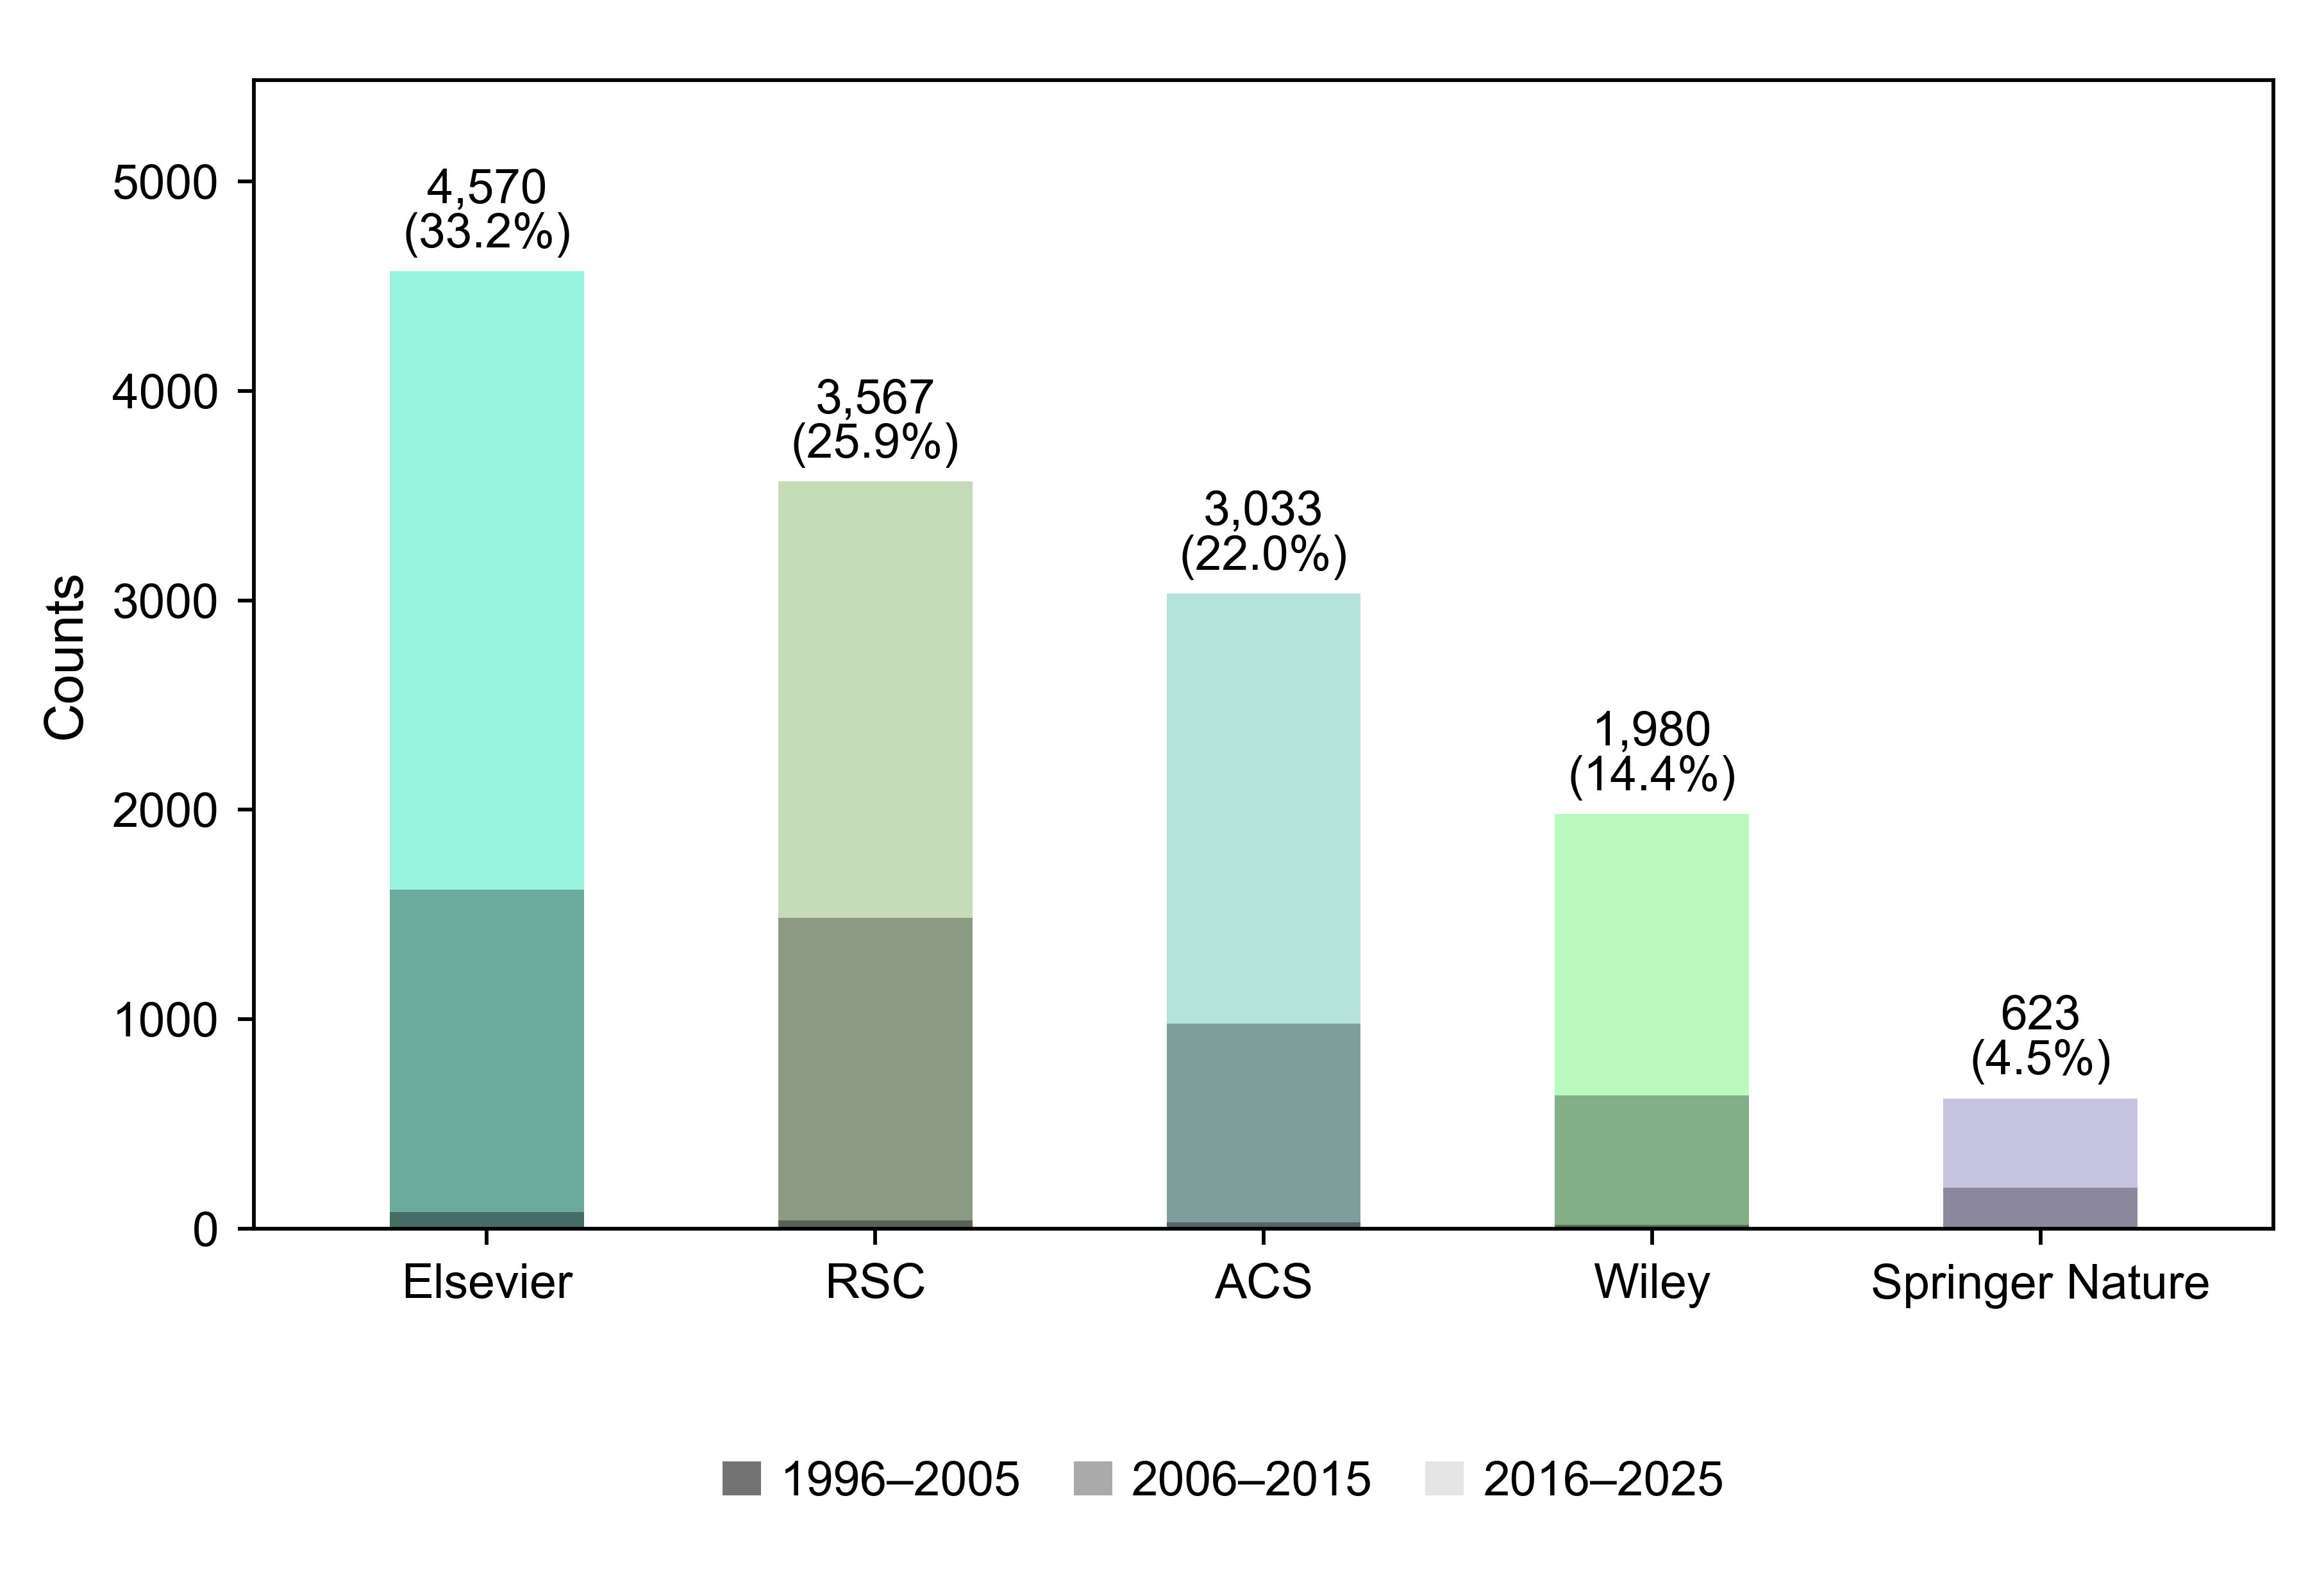

In [3]:
outputs = draw_publisher_coverage(summary, FIGURES)
display(Image(filename=str(outputs["png"]), width=720))

Figure D11. Publisher coverage in the literature corpus, grouped by publication period before abstract triage.